# Does shipment delivery status affect freight costs ?
### Objective
This analysis examines the relationship between **shipment delivery status** and **freight cost**, with a focus on comparing median freight costs for late and on-time shipments across shipment modes.


In [1]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

df = pd.read_csv(r'c:\Users\HP\Downloads\Supply_Chain_Shipment_Pricing_Data.csv')

cols_to_keep = [
    'country', 'vendor', 'shipment mode',
    'product group', 'sub classification',
    'po sent to vendor date', 'scheduled delivery date',
    'delivered to client date',
    'freight cost (usd)', 'line item insurance (usd)'
]
df = df[cols_to_keep]

list_to_date = ['scheduled delivery date', 'delivered to client date']

df = df.copy()                                          # To avoid SettingWithCopyWarning

for col in list_to_date:
    df[col] = pd.to_datetime(df[col], format='mixed')    # mixed format handles different date formats

### Data Aggregation
A pivot table was created to summarize shipment counts by shipment mode and delivery status.

In [2]:
df_delai = df.copy()

df_delai['delay'] = (
    df_delai['scheduled delivery date'] - df_delai['delivered to client date']
    ).dt.days

df_delai['shipment delivery'] = np.where(
    df_delai['delay'] < 0 , 'early',                         # if delay < 0 then 'early'
    np.where(                                                # if delay = 0 then 'on time'
        df_delai['delay'] == 0, 'on time',                   # else 'late'
    'late')
)


## Data Preparation


In [4]:
df_C = df_delai.copy()
df_C

,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay,shipment delivery
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0,on time
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-11-14,2006-11-14,4521.5,NaN,0,on time
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0,on time
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,2006-09-01,2006-09-01,16007.06,NaN,0,on time
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-08-11,2006-08-11,45450.08,NaN,0,on time
...,...,...,...,...,...,...,...,...,...,...,...,...
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),705.79,16,late
10320,Côte d'Ivoire,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-07-31,2015-08-06,See DN-4313 (ID#:83921),161.71,-6,early
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-08-31,2015-08-25,Freight Included in Commodity Cost,5284.04,6,late
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-09-09,2015-08-04,Freight Included in Commodity Cost,134.03,36,late


In [5]:
df_C = df_C[df_C['shipment delivery'].isin(['on time', 'late'])]     # filtring data

df_C

,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay,shipment delivery
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0,on time
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-11-14,2006-11-14,4521.5,NaN,0,on time
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0,on time
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,2006-09-01,2006-09-01,16007.06,NaN,0,on time
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-08-11,2006-08-11,45450.08,NaN,0,on time
...,...,...,...,...,...,...,...,...,...,...,...,...
10318,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),869.66,16,late
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),705.79,16,late
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-08-31,2015-08-25,Freight Included in Commodity Cost,5284.04,6,late
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-09-09,2015-08-04,Freight Included in Commodity Cost,134.03,36,late


### Data Cleaning
To ensure accurate cost analysis, the dataset was filtered and cleaned as follows:
- Removed missing freight cost values
- Converted freight cost values to numeric format
- Retained only shipments with delivery status classified as *on time* or *late*

In [6]:
df_C['freight cost (usd)'].value_counts()

freight cost (usd)
Freight Included in Commodity Cost    1390
Invoiced Separately                    224
9736.1                                  33
See DN-304 (ID#:10589)                  16
6147.18                                 16
                                      ... 
See DN-4265 (ID#:83335)                  1
See DN-4274 (ID#:84472)                  1
26180                                    1
3410                                     1
See DN-4282 (ID#:83919)                  1
Name: count, Length: 5984, dtype: int64

In [7]:
df_C = df_C.copy()

df_C["freight cost (usd)"] = pd.to_numeric(df_C["freight cost (usd)"] , errors="coerce")           #converting to num (text = Nan)

df_C["freight cost (usd)"]

0          780.34
1         4521.50
2         1653.78
3        16007.06
4        45450.08
           ...   
10318         NaN
10319         NaN
10321         NaN
10322         NaN
10323         NaN
Name: freight cost (usd), Length: 9138, dtype: float64

In [8]:
df_C = df_C.dropna(subset=["freight cost (usd)"])

df_C.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5454 entries, 0 to 10316
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   country                    5454 non-null   object        
 1   vendor                     5454 non-null   object        
 2   shipment mode              5245 non-null   object        
 3   product group              5454 non-null   object        
 4   sub classification         5454 non-null   object        
 5   po sent to vendor date     5454 non-null   object        
 6   scheduled delivery date    5454 non-null   datetime64[ns]
 7   delivered to client date   5454 non-null   datetime64[ns]
 8   freight cost (usd)         5454 non-null   float64       
 9   line item insurance (usd)  5266 non-null   float64       
 10  delay                      5454 non-null   int64         
 11  shipment delivery          5454 non-null   object        
dtypes: datetim

### Methodology

Median freight costs were calculated for each delivery status to reduce the influence of extreme values.

In [9]:
df_C_plot = df_C.groupby('shipment delivery')['freight cost (usd)'].median().to_frame()

df_C_plot

,freight cost (usd)
shipment delivery,
late,7363.74
on time,4851.00


### Visualization

A bar chart was used to compare median freight costs between late and on-time shipments.

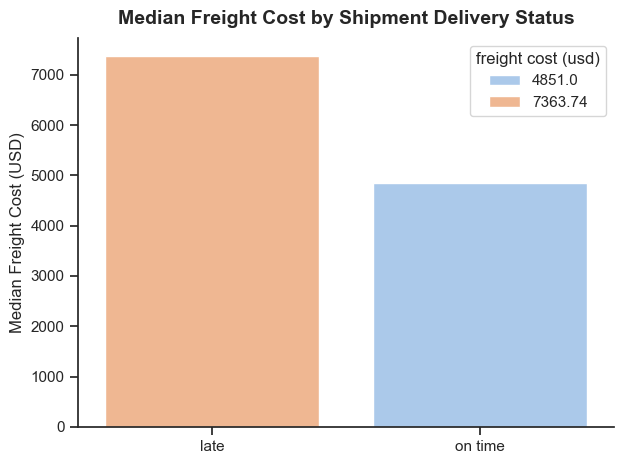

In [10]:
sns.set_theme(style = 'ticks')
sns.barplot(data = df_C_plot,
            x = 'shipment delivery',
            y = 'freight cost (usd)',
            palette = 'pastel',
            hue = 'freight cost (usd)',
            )
sns.despine()

plt.title('Median Freight Cost by Shipment Delivery Status', pad = 10, fontsize = 14, fontweight = 'bold')
plt.xlabel('')
plt.ylabel('Median Freight Cost (USD)')

plt.tight_layout()
plt.show()

**Insight:**  
- Late shipments have a **substantially higher median freight cost** (≈ USD 7.4K) compared to **on-time shipments** (≈ USD 4.9K).  
- Delivery delays are directly associated with a **~50% increase in freight spend**, driven by expedites, re-routing, and exception handling.  
- Reducing late deliveries represents a **high-impact lever** to lower overall logistics costs while improving service performance.


---

# Which vendors are the most reliable ?

### Methodology
The top seven vendors were identified based on the total number of shipments. Shipment delivery outcomes (early, late, on time) were then aggregated for each vendor using a pivot table.


### Data Aggregation

In [11]:
vd_i = df_delai['vendor'].value_counts().head(7).index         # Top 7 vendors

vd_i

Index(['SCMS from RDC', 'Orgenics, Ltd', 'S. BUYS WHOLESALER',
       'Aurobindo Pharma Limited', 'Trinity Biotech, Plc',
       'ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV)', 'PHARMACY DIRECT'],
      dtype='object', name='vendor')

In [12]:
df_vd_to7 = df_delai[df_delai['vendor'].isin(vd_i)]

df_vd_top7_pvt = df_vd_to7.pivot_table(index='vendor',
                                          columns = 'shipment delivery',
                                          aggfunc = 'size',
                                          fill_value = 0,
                        )


df_vd_top7_pvt

shipment delivery,early,late,on time
vendor,,,
ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV),4,2,341
Aurobindo Pharma Limited,94,22,552
"Orgenics, Ltd",98,64,592
PHARMACY DIRECT,0,0,326
S. BUYS WHOLESALER,11,240,464
SCMS from RDC,927,2409,2068
"Trinity Biotech, Plc",1,2,353


### Visualization

A horizontal bar chart was used to compare delivery outcomes across the top seven vendors.

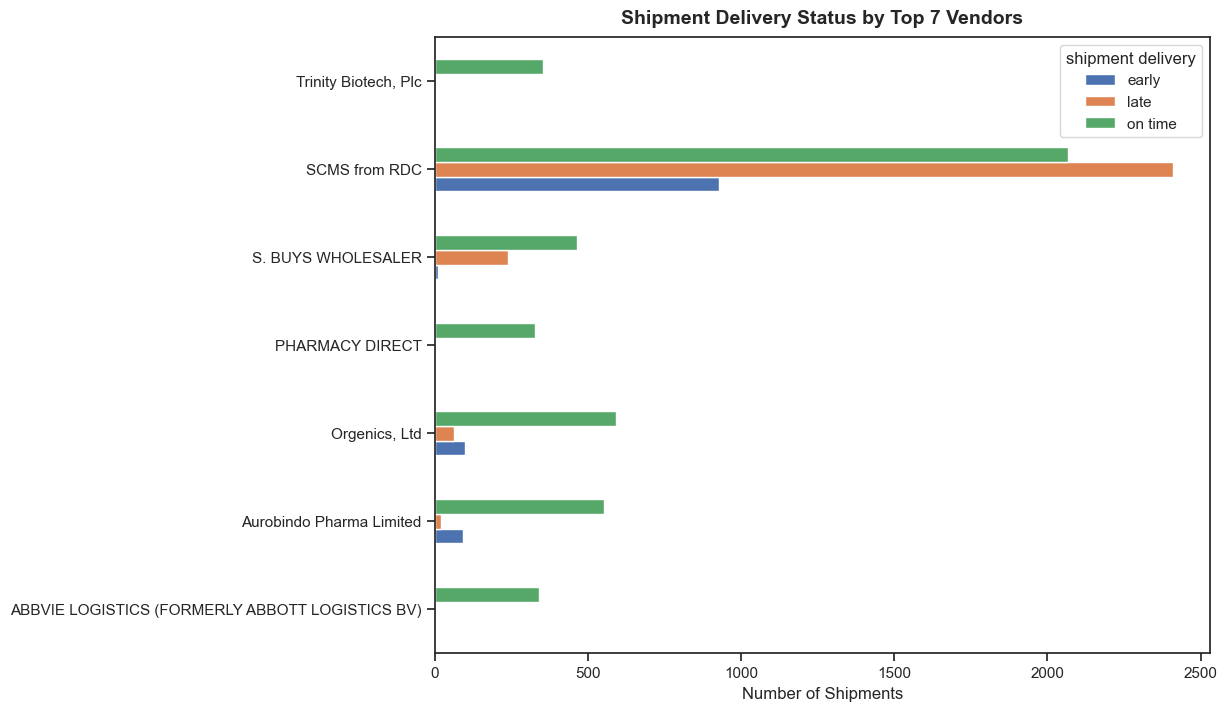

In [13]:
df_vd_top7_pvt.plot(kind = 'barh',
            figsize = (10,8),
            xlabel = '',
            ylabel = '',
            legend = True,
             )

plt.title('Shipment Delivery Status by Top 7 Vendors', pad = 10, fontsize = 14, fontweight = 'bold')
plt.xlabel('Number of Shipments')

plt.show()

**Insight:**  
- Shipment volume and delivery performance are **highly concentrated with SCMS from RDC**, which shows both the largest volume and a **notably high number of late deliveries**, creating outsized impact on overall performance.  
- Other vendors (e.g., **Organics, Ltd, Aurobindo Pharma Limited, S. BUYS WHOLESALER**) demonstrate **more stable on-time performance**, though at lower shipment volumes.  
- **Focusing performance improvement efforts on SCMS from RDC** would yield the greatest immediate benefit, while leveraging best practices from smaller, more reliable vendors could improve consistency across the vendor base.

